# April 28 Plots

This notebook reads the `runner_test_april28th` sweep logs and plots:
- the two-qubit-only sweep
- the one-qubit-only sweep

In [154]:
from pathlib import Path
import ast
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

LOG_DIR = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april28th_1link/graph_two_qubit_gate_sweep_only_2q_noise")

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"meas=(?P<meas>[0-9.]+|cfg),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"physbell=(?P<physbell>[0-9.]+|cfg),"
    r"ts=(?P<ts>\d{8}_\d{6})"
)

critical_e2e_re = re.compile(
    r"critical_e2e run_id=(?P<run_id>\d+) "
    r"latency_ps=(?P<latency_ps>[-+0-9.eE]+|None) "
    r"fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+|None) "
    r"fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+|None) "
    r"fidelity_delta=(?P<fidelity_delta>[-+0-9.eE]+|None)"
)

gate_1q_attempts_re = re.compile(
    r"gate_1q_attempts_by_block=(?P<attempts>\{.*?\}) gate_2q_by_block_pair="
)
gate_2q_attempts_re = re.compile(
    r"gate_2q_attempts_by_block_pair=(?P<attempts>\{.*?\}) gate_2q_observed_rate_by_block_pair="
)
measurement_attempts_re = re.compile(
    r"measurement_attempts_by_qubit=(?P<attempts>\{.*?\}) "
)


def load_april28_logs(log_dir: Path) -> pd.DataFrame:
    """Load flat run-level data from the April 28 runner-test logs.

    Args:
        log_dir: Directory containing runner_test_april28th sweep logs.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows: list[dict[str, float | int | str]] = []

    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue

        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = critical_e2e_re.search(line)
                if line_match is None:
                    continue

                rows.append({
                    "log_name": path.name,
                    "nodes": int(meta["nodes"]),
                    "css_code": meta["code"],
                    "elementary_link_km": float(meta["dist"]),
                    "gate_fidelity": float(meta["gate"]),
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "measurement_fidelity": float(meta["meas"]),
                    "initialization_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": float(meta["physbell"]),
                    "t1_sec": float(meta["t1"]),
                    "t2_sec": float(meta["t2"]),
                    "ft_prep_mode": meta["ft"],
                    "correction_mode": meta["ccorr"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ps": float(line_match["latency_ps"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]),
                    "fidelity_delta": float(line_match["fidelity_delta"]),
                })

    return pd.DataFrame(rows)


def load_attempt_summary(log_dir: Path, attempt_re: re.Pattern[str], sweep_column: str, meta_key: str) -> pd.DataFrame:
    """Load per-file total attempt counts from critical_noise logs.

    Args:
        log_dir: Directory containing sweep log files.
        attempt_re: Regex extracting the attempt dictionary.
        sweep_column: Output column name for the swept parameter.
        meta_key: Key from filename metadata for the swept parameter.

    Returns:
        pd.DataFrame: One row per log file with total attempts and runs.
    """
    rows: list[dict[str, float | int | str]] = []

    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue

        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        total_attempts = 0
        run_count = 0

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = attempt_re.search(line)
                if line_match is None:
                    continue

                attempts = ast.literal_eval(line_match.group("attempts"))
                total_attempts += sum(int(value) for value in attempts.values())
                run_count += 1

        if run_count == 0:
            continue

        rows.append(
            {
                "log_name": path.name,
                sweep_column: float(meta[meta_key]),
                "attempts": total_attempts,
                "attempts_per_run": float(total_attempts) / float(run_count),
                "run_count_noise": run_count,
            }
        )

    return pd.DataFrame(rows)


def set_zoom_limits(ax, x_values: pd.Series, plotted_series: list[pd.Series], x_min: float = 0.995) -> None:
    """Set common plot limits for the high-fidelity zoomed view.

    Args:
        ax: Matplotlib axes to update.
        x_values: Sweep x-values.
        plotted_series: Y-series shown on the plot.
        x_min: Left x-limit.

    Returns:
        None.
    """
    x_last = float(x_values.iloc[-1])
    ax.set_xlim(x_min, x_last)
    ax.set_ylim(0.95, 1.001)


run_df = load_april28_logs(LOG_DIR)
run_df.head()


,log_name,nodes,css_code,elementary_link_km,gate_fidelity,two_qubit_gate_fidelity,measurement_fidelity,initialization_fidelity,physical_bell_pair_fidelity,t1_sec,t2_sec,ft_prep_mode,correction_mode,run_id,latency_ps,fidelity_raw,fidelity_corrected,fidelity_delta
0,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...",2,"[[7,1,3]]",1.0,1.0,0.99,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,1,3.270141e+09,1.0,1.0,0.0
1,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...",2,"[[7,1,3]]",1.0,1.0,0.99,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,2,3.050044e+09,0.0,1.0,1.0
2,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...",2,"[[7,1,3]]",1.0,1.0,0.99,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,3,2.170114e+09,1.0,1.0,0.0
3,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...",2,"[[7,1,3]]",1.0,1.0,0.99,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,4,2.005029e+09,1.0,1.0,0.0
4,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...",2,"[[7,1,3]]",1.0,1.0,0.99,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,5,3.875179e+09,0.0,1.0,1.0


In [155]:
twoq_attempt_df = load_attempt_summary(
    LOG_DIR,
    gate_2q_attempts_re,
    "two_qubit_gate_fidelity",
    "twoq",
)

summary_df = (
    run_df.groupby("two_qubit_gate_fidelity", as_index=False)
    .agg(
        fidelity_raw=("fidelity_raw", "mean"),
        fidelity_corrected=("fidelity_corrected", "mean"),
        fidelity_delta=("fidelity_delta", "mean"),
        avg_latency_ps=("latency_ps", "mean"),
        run_count=("run_id", "count"),
    )
    .sort_values("two_qubit_gate_fidelity")
)

summary_df = summary_df.merge(
    twoq_attempt_df[["two_qubit_gate_fidelity", "attempts", "attempts_per_run"]],
    on="two_qubit_gate_fidelity",
    how="left",
)

summary_df["p_2q"] = 1.25 * (1.0 - summary_df["two_qubit_gate_fidelity"])
summary_df["theory_corrected_first_order_rough"] = np.clip(
    1.0 - summary_df["attempts_per_run"] * summary_df["p_2q"],
    0.0,
    1.0,
)
summary_df["theory_corrected_second_order_rough"] = np.clip(
    1.0
    - (
        summary_df["attempts_per_run"]
        * (summary_df["attempts_per_run"] - 1.0)
        / 2.0
    )
    * (summary_df["p_2q"] ** 2),
    0.0,
    1.0,
)

summary_df


,two_qubit_gate_fidelity,fidelity_raw,fidelity_corrected,fidelity_delta,avg_latency_ps,run_count,attempts,attempts_per_run,p_2q,theory_corrected_first_order_rough,theory_corrected_second_order_rough
0,0.9900,0.810518,0.981219,0.170701,2.692551e+09,2396,37397,37.397000,0.012500,0.532537,0.893661
1,0.9900,0.810518,0.981219,0.170701,2.692551e+09,2396,37353,37.353000,0.012500,0.533087,0.893915
2,0.9900,0.810518,0.981219,0.170701,2.692551e+09,2396,14784,37.333333,0.012500,0.533333,0.894028
3,0.9950,0.898914,0.994987,0.096074,2.697843e+09,2394,36781,36.781000,0.006250,0.770119,0.974296
4,0.9950,0.898914,0.994987,0.096074,2.697843e+09,2394,36693,36.693000,0.006250,0.770669,0.974420
5,0.9950,0.898914,0.994987,0.096074,2.697843e+09,2394,14492,36.781726,0.006250,0.770114,0.974295
6,0.9960,0.922371,0.997913,0.075543,2.669980e+09,2396,36451,36.451000,0.005000,0.817745,0.983847
7,0.9960,0.922371,0.997913,0.075543,2.669980e+09,2396,36517,36.517000,0.005000,0.817415,0.983788
8,0.9960,0.922371,0.997913,0.075543,2.669980e+09,2396,14575,36.805556,0.005000,0.815972,0.983527
9,0.9970,0.944514,0.997497,0.052983,2.655782e+09,2397,36407,36.407000,0.003750,0.863474,0.990936


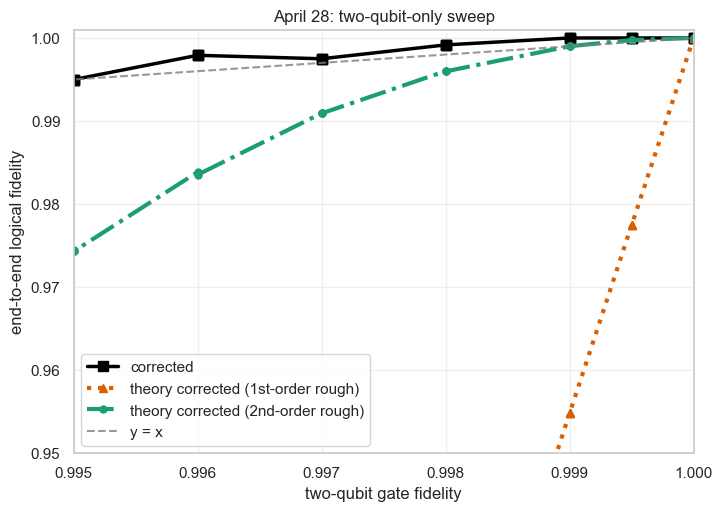

In [156]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(
    summary_df["two_qubit_gate_fidelity"],
    summary_df["fidelity_corrected"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="corrected",
)
ax.plot(
    summary_df["two_qubit_gate_fidelity"],
    summary_df["theory_corrected_first_order_rough"],
    marker="^",
    markersize=6,
    linestyle=":",
    linewidth=3,
    color="#d95f02",
    label="theory corrected (1st-order rough)",
)
ax.plot(
    summary_df["two_qubit_gate_fidelity"],
    summary_df["theory_corrected_second_order_rough"],
    marker="o",
    markersize=5,
    linestyle="-.",
    linewidth=3,
    color="#1b9e77",
    label="theory corrected (2nd-order rough)",
)
ax.plot(
    [0.99, float(summary_df["two_qubit_gate_fidelity"].iloc[-1])],
    [0.99, float(summary_df["two_qubit_gate_fidelity"].iloc[-1])],
    linestyle="--",
    linewidth=1.5,
    color="#7f7f7f",
    alpha=0.8,
    label="y = x",
)

ax.set_xlabel("two-qubit gate fidelity")
ax.set_ylabel("end-to-end logical fidelity")
ax.set_title("April 28: two-qubit-only sweep")
set_zoom_limits(
    ax,
    summary_df["two_qubit_gate_fidelity"],
    [
        summary_df["fidelity_corrected"],
        summary_df["theory_corrected_first_order_rough"],
        summary_df["theory_corrected_second_order_rough"],
    ],
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [157]:
out_path = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th") / "april28_two_qubit_only_sweep.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
out_path


PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/april28_two_qubit_only_sweep.png')

In [158]:
LOG_DIR_1Q = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april28th_1link/graph_one_qubit_gate_sweep_only_1q_noise")

run_df_1q = load_april28_logs(LOG_DIR_1Q)
run_df_1q.head()


,log_name,nodes,css_code,elementary_link_km,gate_fidelity,two_qubit_gate_fidelity,measurement_fidelity,initialization_fidelity,physical_bell_pair_fidelity,t1_sec,t2_sec,ft_prep_mode,correction_mode,run_id,latency_ps,fidelity_raw,fidelity_corrected,fidelity_delta
0,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=0.9,two...",2,"[[7,1,3]]",1.0,0.9,1.0,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,1,4.205129e+09,0.0,0.0,0.0
1,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=0.9,two...",2,"[[7,1,3]]",1.0,0.9,1.0,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,2,3.435161e+09,1.0,0.0,-1.0
2,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=0.9,two...",2,"[[7,1,3]]",1.0,0.9,1.0,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,3,1.950009e+09,0.0,0.0,0.0
3,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=0.9,two...",2,"[[7,1,3]]",1.0,0.9,1.0,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,4,1.950009e+09,0.0,0.0,0.0
4,"line_2_2G,code=[[7,1,3]],dist=1.0,gate=0.9,two...",2,"[[7,1,3]]",1.0,0.9,1.0,1.0,1.0,1.0,1.000000e+12,1.000000e+12,minimal,cec,5,1.730061e+09,1.0,0.0,-1.0


In [159]:
oneq_attempt_df = load_attempt_summary(
    LOG_DIR_1Q,
    gate_1q_attempts_re,
    "gate_fidelity",
    "gate",
)

summary_df_1q = (
    run_df_1q.groupby("gate_fidelity", as_index=False)
    .agg(
        fidelity_raw=("fidelity_raw", "mean"),
        fidelity_corrected=("fidelity_corrected", "mean"),
        fidelity_delta=("fidelity_delta", "mean"),
        avg_latency_ps=("latency_ps", "mean"),
        run_count=("run_id", "count"),
    )
    .sort_values("gate_fidelity")
)

summary_df_1q = summary_df_1q.merge(
    oneq_attempt_df[["gate_fidelity", "attempts", "attempts_per_run"]],
    on="gate_fidelity",
    how="left",
)

summary_df_1q["p_1q"] = 1.5 * (1.0 - summary_df_1q["gate_fidelity"])
summary_df_1q["theory_corrected_first_order_rough"] = np.clip(
    1.0 - summary_df_1q["attempts_per_run"] * summary_df_1q["p_1q"],
    0.0,
    1.0,
)
summary_df_1q["theory_corrected_second_order_rough"] = np.clip(
    1.0
    - (
        summary_df_1q["attempts_per_run"]
        * (summary_df_1q["attempts_per_run"] - 1.0)
        / 2.0
    )
    * (summary_df_1q["p_1q"] ** 2),
    0.0,
    1.0,
)

summary_df_1q


,gate_fidelity,fidelity_raw,fidelity_corrected,fidelity_delta,avg_latency_ps,run_count,attempts,attempts_per_run,p_1q,theory_corrected_first_order_rough,theory_corrected_second_order_rough
0,0.9000,0.386667,0.453333,0.066667,2.665993e+09,1200,11615,58.075,0.15000,0.000000,0.000000
1,0.9000,0.386667,0.453333,0.066667,2.665993e+09,1200,57994,57.994,0.15000,0.000000,0.000000
2,0.9950,0.777500,0.973333,0.195833,2.674383e+09,1200,11706,58.530,0.00750,0.561025,0.905297
3,0.9950,0.777500,0.973333,0.195833,2.674383e+09,1200,58208,58.208,0.00750,0.563440,0.906345
4,0.9960,0.814167,0.978333,0.164167,2.672138e+09,1200,11662,58.310,0.00600,0.650140,0.939849
5,0.9960,0.814167,0.978333,0.164167,2.672138e+09,1200,58234,58.234,0.00600,0.650596,0.940007
6,0.9970,0.850000,0.989583,0.139583,2.708715e+09,1200,11861,59.305,0.00450,0.733127,0.964990
7,0.9970,0.850000,0.989583,0.139583,2.708715e+09,1200,58312,58.312,0.00450,0.737596,0.966162
8,0.9980,0.894167,0.994583,0.100417,2.714263e+09,1200,11572,57.860,0.00300,0.826420,0.985195
9,0.9980,0.894167,0.994583,0.100417,2.714263e+09,1200,58583,58.583,0.00300,0.824251,0.984820


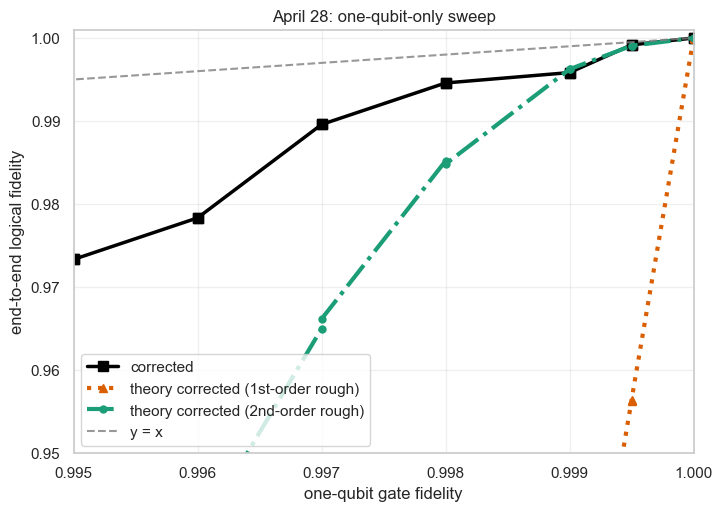

In [160]:
fig_1q, ax_1q = plt.subplots(figsize=(8, 5.5))
ax_1q.plot(
    summary_df_1q["gate_fidelity"],
    summary_df_1q["fidelity_corrected"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="corrected",
)
ax_1q.plot(
    summary_df_1q["gate_fidelity"],
    summary_df_1q["theory_corrected_first_order_rough"],
    marker="^",
    markersize=6,
    linestyle=":",
    linewidth=3,
    color="#d95f02",
    label="theory corrected (1st-order rough)",
)
ax_1q.plot(
    summary_df_1q["gate_fidelity"],
    summary_df_1q["theory_corrected_second_order_rough"],
    marker="o",
    markersize=5,
    linestyle="-.",
    linewidth=3,
    color="#1b9e77",
    label="theory corrected (2nd-order rough)",
)
ax_1q.plot(
    [0.99, float(summary_df_1q["gate_fidelity"].iloc[-1])],
    [0.99, float(summary_df_1q["gate_fidelity"].iloc[-1])],
    linestyle="--",
    linewidth=1.5,
    color="#7f7f7f",
    alpha=0.8,
    label="y = x",
)

ax_1q.set_xlabel("one-qubit gate fidelity")
ax_1q.set_ylabel("end-to-end logical fidelity")
ax_1q.set_title("April 28: one-qubit-only sweep")
set_zoom_limits(
    ax_1q,
    summary_df_1q["gate_fidelity"],
    [
        summary_df_1q["fidelity_corrected"],
        summary_df_1q["theory_corrected_first_order_rough"],
        summary_df_1q["theory_corrected_second_order_rough"],
    ],
)
ax_1q.legend()
ax_1q.grid(True, alpha=0.3)
plt.show()


In [161]:
out_path_1q = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th") / "april28_one_qubit_only_sweep.png"
out_path_1q.parent.mkdir(parents=True, exist_ok=True)
fig_1q.savefig(out_path_1q, dpi=150, bbox_inches="tight")
out_path_1q


PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/april28_one_qubit_only_sweep.png')

In [162]:
LOG_DIR_MEAS = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april28th/graph_measurement_fidelity_sweep_only_meas_noise")

run_df_meas = load_april28_logs(LOG_DIR_MEAS)
run_df_meas.head()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/patange/Documents/Argonne/QEC/log/runner_test_april28th/graph_measurement_fidelity_sweep_only_meas_noise'

In [ ]:
measurement_attempt_df = load_attempt_summary(
    LOG_DIR_MEAS,
    measurement_attempts_re,
    "measurement_fidelity",
    "meas",
)

summary_df_meas = (
    run_df_meas.groupby("measurement_fidelity", as_index=False)
    .agg(
        fidelity_raw=("fidelity_raw", "mean"),
        fidelity_corrected=("fidelity_corrected", "mean"),
        fidelity_delta=("fidelity_delta", "mean"),
        avg_latency_ps=("latency_ps", "mean"),
        run_count=("run_id", "count"),
    )
    .sort_values("measurement_fidelity")
)

summary_df_meas = summary_df_meas.merge(
    measurement_attempt_df[["measurement_fidelity", "attempts", "attempts_per_run"]],
    on="measurement_fidelity",
    how="left",
)

summary_df_meas["p_meas"] = 1.0 - summary_df_meas["measurement_fidelity"]

alpha_fit = (
    (1.0 - summary_df_meas.loc[summary_df_meas["p_meas"] > 0, "fidelity_corrected"])
    / (
        summary_df_meas.loc[summary_df_meas["p_meas"] > 0, "attempts_per_run"]
        * summary_df_meas.loc[summary_df_meas["p_meas"] > 0, "p_meas"]
    )
).mean()

pair_count = (
    summary_df_meas["attempts_per_run"]
    * (summary_df_meas["attempts_per_run"] - 1.0)
    / 2.0
)
beta_fit = (
    (1.0 - summary_df_meas.loc[summary_df_meas["p_meas"] > 0, "fidelity_corrected"])
    / (
        pair_count.loc[summary_df_meas["p_meas"] > 0]
        * (summary_df_meas.loc[summary_df_meas["p_meas"] > 0, "p_meas"] ** 2)
    )
).mean()

summary_df_meas["theory_corrected_first_order_fit"] = np.clip(
    1.0 - alpha_fit * summary_df_meas["attempts_per_run"] * summary_df_meas["p_meas"],
    0.0,
    1.0,
)
summary_df_meas["theory_corrected_second_order_fit"] = np.clip(
    1.0 - beta_fit * pair_count * (summary_df_meas["p_meas"] ** 2),
    0.0,
    1.0,
)

summary_df_meas


,measurement_fidelity,fidelity_raw,fidelity_corrected,fidelity_delta,avg_latency_ps,run_count,attempts,attempts_per_run,p_meas,theory_corrected_first_order_fit,theory_corrected_second_order_fit
0,0.9900,0.81150,0.96425,0.15275,2.648932e+09,2000,102903,102.903,0.0100,0.966377,0.815341
1,0.9950,0.88650,0.98150,0.09500,2.703715e+09,2000,103505,103.505,0.0050,0.983090,0.953291
2,0.9960,0.91175,0.98550,0.07375,2.657725e+09,2000,103911,103.911,0.0040,0.986419,0.969870
3,0.9970,0.93550,0.99125,0.05575,2.672252e+09,2000,103569,103.569,0.0030,0.989848,0.983164
4,0.9980,0.95575,0.99125,0.03550,2.676060e+09,2000,103651,103.651,0.0020,0.993227,0.992505
5,0.9990,0.97700,0.99700,0.02000,2.682633e+09,2000,103384,103.384,0.0010,0.996622,0.998136
6,0.9995,0.98675,0.99875,0.01200,2.685611e+09,2000,104357,104.357,0.0005,0.998295,0.999525
7,1.0000,1.00000,1.00000,0.00000,2.691070e+09,2000,103532,103.532,0.0000,1.000000,1.000000


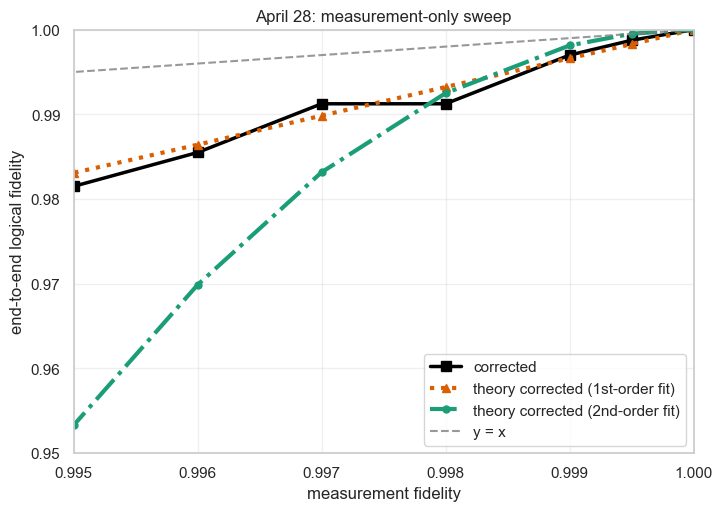

In [ ]:
fig_meas, ax_meas = plt.subplots(figsize=(8, 5.5))
ax_meas.plot(
    summary_df_meas["measurement_fidelity"],
    summary_df_meas["fidelity_corrected"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="corrected",
)
ax_meas.plot(
    summary_df_meas["measurement_fidelity"],
    summary_df_meas["theory_corrected_first_order_fit"],
    marker="^",
    markersize=6,
    linestyle=":",
    linewidth=3,
    color="#d95f02",
    label="theory corrected (1st-order fit)",
)
ax_meas.plot(
    summary_df_meas["measurement_fidelity"],
    summary_df_meas["theory_corrected_second_order_fit"],
    marker="o",
    markersize=5,
    linestyle="-.",
    linewidth=3,
    color="#1b9e77",
    label="theory corrected (2nd-order fit)",
)
ax_meas.plot(
    [0.99, float(summary_df_meas["measurement_fidelity"].iloc[-1])],
    [0.99, float(summary_df_meas["measurement_fidelity"].iloc[-1])],
    linestyle="--",
    linewidth=1.5,
    color="#7f7f7f",
    alpha=0.8,
    label="y = x",
)

ax_meas.set_xlabel("measurement fidelity")
ax_meas.set_ylabel("end-to-end logical fidelity")
ax_meas.set_title("April 28: measurement-only sweep")
set_zoom_limits(
    ax_meas,
    summary_df_meas["measurement_fidelity"],
    [
        summary_df_meas["fidelity_corrected"],
        summary_df_meas["theory_corrected_first_order_fit"],
        summary_df_meas["theory_corrected_second_order_fit"],
    ],
)
ax_meas.legend()
ax_meas.grid(True, alpha=0.3)
plt.show()


In [ ]:
out_path_meas = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th") / "april28_measurement_only_sweep.png"
out_path_meas.parent.mkdir(parents=True, exist_ok=True)
fig_meas.savefig(out_path_meas, dpi=150, bbox_inches="tight")
out_path_meas


PosixPath('/Users/patange/Documents/Argonne/QEC/plot_pngs/april28_measurement_only_sweep.png')